### Non-Linear Methods

The case study is based on the Ames Housing dataset, which describes the sale of individual residential properties in Ames, Iowa from 2006 to 2010. The details of the dataset are provided in https://jse.amstat.org/v19n3/decock/DataDocumentation.txt.

In this study, we consider only a subset of the features / predictors:
* OverallQual: Rates the overall material and finish of the property.
* YearRemodAdd : Remodel date (same as construction date if no remodeling or additions).
* BsmtUnfSF : Unfinished square feet of basement area.
* TotalBsmtSF: Total square feet of basement area.
* 1stFlrSF: First Floor square feet.
* 2ndFlrSF: Second floor square feet.
* GarageCars: Size of garage in car capacity.

In [155]:
# Loading libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score,cross_validate, train_test_split
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)

In [74]:
# Load the dataset and ensure that Ames_no-missing-value_train.csv is located in the same folder as this script.
df_week3 = pd.read_csv("Ames_no-missing-value_train.csv")
df_X = df_week3.drop(columns='SalePrice')
df_X = df_X[['OverallQual', 'YearRemodAdd','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF', 'GarageCars']]
df_y = df_week3['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42)

In [4]:
df_X.describe()

,OverallQual,YearRemodAdd,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageCars
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,6.093964,1984.834019,567.096708,1052.537037,1158.851166,345.762003,1.766118
std,1.376369,20.641760,442.087187,414.982320,372.039498,435.423924,0.747104
min,1.000000,1950.000000,0.000000,0.000000,334.000000,0.000000,0.000000
25%,5.000000,1967.000000,223.000000,795.250000,882.000000,0.000000,1.000000
50%,6.000000,1994.000000,477.500000,991.000000,1086.000000,0.000000,2.000000
75%,7.000000,2004.000000,808.000000,1296.750000,1390.750000,728.000000,2.000000
max,10.000000,2010.000000,2336.000000,3206.000000,3228.000000,2065.000000,4.000000


In [75]:
lr = LinearRegression()

rmse_lr = -cross_val_score(lr, X_train, y_train, cv=5,scoring='neg_root_mean_squared_error')
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (rmse_lr.mean(), rmse_lr.std()))

RMSE: 33564.99 ; Standard deviation : 3244.75


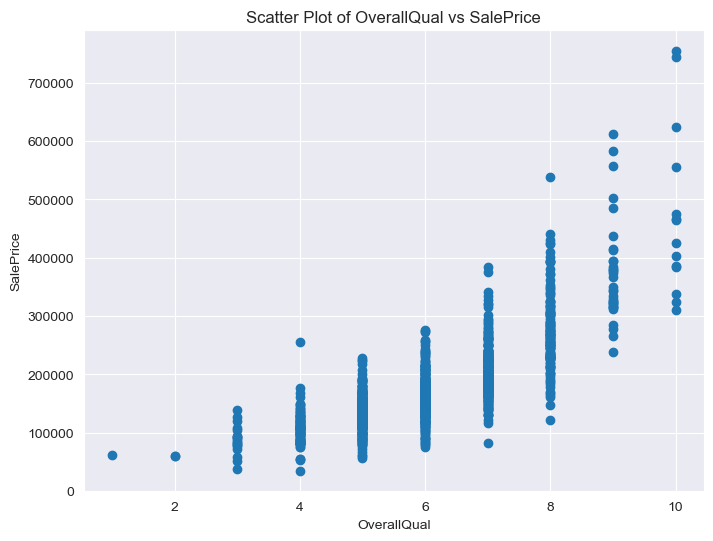

In [77]:
sns.set_style('darkgrid')
plt.figure(figsize=(8, 6))
plt.scatter(X_train[['OverallQual']], y_train)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('Scatter Plot of OverallQual vs SalePrice')
plt.show()

### Activity 1: Polynomial Regression

Demonstration of Polynomial regression with a single feature OverallQual.

In [163]:
import numpy as np, pandas as pd
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize ,
poly ,
ModelSpec as MS)

from ISLP.transforms import (BSpline ,
NaturalSpline)
from ISLP.models import bs, ns

from ISLP.models import sklearn_sm

Perform 5 fold cross validation with the linear regression model implemented in statsmodels. Only a single predictor OverallQual is used in this experiment. *sklearn_sm()* takes a model from statsmodels as its first argument and produces a wrapper for using that model in cross_validate.

In [164]:
overall_quality = X_train[['OverallQual']]
qual_model = sklearn_sm(sm.OLS, MS(['OverallQual']))
cv_ols_qual = cross_validate(qual_model, overall_quality, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (-np.mean(cv_ols_qual['test_score']), np.std(cv_ols_qual['test_score'])))

RMSE: 49714.37 ; Standard deviation : 5251.39


Apply [poly()](https://islp.readthedocs.io/en/latest/api/generated/ISLP.models.model_spec.html#ISLP.models.model_spec.poly) to transform the feature *'OverallQual'* into the polynomial form.

In [165]:
poly_qual = MS([poly('OverallQual', degree=3)])
lr_poly_qual_model = sm.OLS(y_train, poly_qual.fit_transform(overall_quality)).fit()
summarize(lr_poly_qual_model)

,coef,std err,t,P>|t|
intercept,180800.0,1315.89,137.415,0.0
"poly(OverallQual, degree=3)[0]",2168000.0,44900.00,48.242,0.0
"poly(OverallQual, degree=3)[1]",708600.0,44900.00,15.771,0.0
"poly(OverallQual, degree=3)[2]",217700.0,44900.00,4.845,0.0


In [162]:
X_test_qual = MS([poly('OverallQual', degree=3)]).fit_transform(X_test[['OverallQual']])
predictions_qual = lr_poly_qual_model.predict(X_test_qual)
mse = mean_squared_error(y_test, predictions_qual)
rmse = (mse)**(1/2)
print("The RMSE on the validation set is %f" % rmse)

The RMSE on the validation set is 79229.541358


In [167]:
X_test.head()

,OverallQual,YearRemodAdd,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageCars
1320,7,1992,76,750,1061,862,2
836,6,1973,153,483,483,504,1
413,5,1950,1008,1008,1028,0,2
522,6,1950,605,1004,1004,660,2
1035,9,2008,598,1620,1620,0,3


In [175]:
MS([poly('OverallQual', degree=3, raw=True)]).fit_transform(X_test[['OverallQual']]) # If raw=False, QR decomposition is applied to the transformed data frame.

,intercept,"poly(OverallQual, degree=3, raw=True)[0]","poly(OverallQual, degree=3, raw=True)[1]","poly(OverallQual, degree=3, raw=True)[2]"
1320,1.0,7.0,49.0,343.0
836,1.0,6.0,36.0,216.0
413,1.0,5.0,25.0,125.0
522,1.0,6.0,36.0,216.0
1035,1.0,9.0,81.0,729.0
...,...,...,...,...
479,1.0,4.0,16.0,64.0
1359,1.0,7.0,49.0,343.0
1413,1.0,7.0,49.0,343.0
650,1.0,4.0,16.0,64.0


In [135]:
poly_qual_model = sklearn_sm(sm.OLS, MS([poly('OverallQual', degree=3)]))
cv_ols_qual = cross_validate(poly_qual_model, overall_quality, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (-np.mean(cv_ols_qual['test_score']), np.std(cv_ols_qual['test_score'])))

RMSE: 45088.42 ; Standard deviation : 3936.21


Put all features together, identify which degree is optimal.

In [136]:
for degree in [2,3,4]:
    poly_model = sklearn_sm(sm.OLS, MS(['YearRemodAdd','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF', 'GarageCars', poly('OverallQual', degree=degree)]))
    cv_poly = cross_validate(poly_model, X_train, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
    print("Degree = %i ;  RMSE: %0.2f ; Standard deviation : %0.2f" % (degree,-np.mean(cv_poly['test_score']), np.std(cv_poly['test_score'])))

Degree = 2 ;  RMSE: 29979.80 ; Standard deviation : 3258.82
Degree = 3 ;  RMSE: 29693.29 ; Standard deviation : 3116.64
Degree = 4 ;  RMSE: 29743.34 ; Standard deviation : 3118.04


Perform 5 fold cross validation with the linear regression model with a single predictor GarageCars.

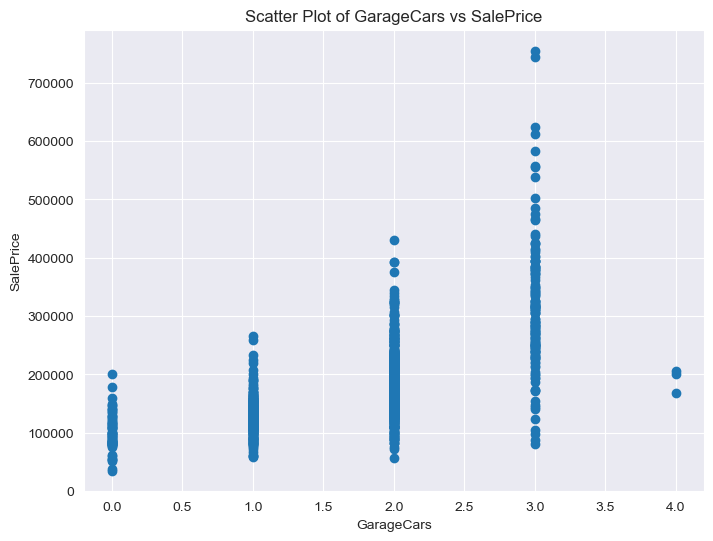

In [78]:
sns.set_style('darkgrid')
plt.figure(figsize=(8, 6))
plt.scatter(X_train[['GarageCars']], y_train)
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.title('Scatter Plot of GarageCars vs SalePrice')
plt.show()

In [137]:
garage_cars = X_train[['GarageCars']]
garage_model = sklearn_sm(sm.OLS, MS(['GarageCars']))
cv_ols_garage = cross_validate(garage_model, garage_cars, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (-np.mean(cv_ols_garage['test_score']), np.std(cv_ols_garage['test_score'])))

RMSE: 61782.81 ; Standard deviation : 7007.69


#### Task 1.1 Apply polynomial regression to the single feature model with GarageCars and identify which degree achieves the lowest CV errors.

In [138]:
for degree in [2,3,4,5,6]:
    poly_garage_model = sklearn_sm(sm.OLS, MS([poly('GarageCars', degree=degree)]))
    cv_ols_garage = cross_validate(poly_garage_model, garage_cars, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
    print("Degree = %i ; RMSE: %0.2f ; Standard deviation : %0.2f" % (degree, -np.mean(cv_ols_garage['test_score']), np.std(cv_ols_garage['test_score'])))

Degree = 2 ; RMSE: 59328.28 ; Standard deviation : 6897.85
Degree = 3 ; RMSE: 59568.69 ; Standard deviation : 6840.82
Degree = 4 ; RMSE: 57434.18 ; Standard deviation : 6780.49
Degree = 5 ; RMSE: 57434.18 ; Standard deviation : 6780.49
Degree = 6 ; RMSE: 57434.18 ; Standard deviation : 6780.49


### Activity 2: Splines.

Demonstration with a single feature model OverallQual.

In [139]:
overall_quality.head()

,OverallQual
254,5
1065,6
864,5
798,5
380,5


In [140]:
bs_qual = MS([bs('OverallQual',degree=3, internal_knots=[5,7])])
X_bs_qual = bs_qual.fit_transform(overall_quality)
X_bs_qual.head()

,intercept,"bs(OverallQual, degree=3, internal_knots=[5, 7])[0]","bs(OverallQual, degree=3, internal_knots=[5, 7])[1]","bs(OverallQual, degree=3, internal_knots=[5, 7])[2]","bs(OverallQual, degree=3, internal_knots=[5, 7])[3]","bs(OverallQual, degree=3, internal_knots=[5, 7])[4]"
254,1.0,0.111111,0.592593,0.296296,0.00,0.0
1065,1.0,0.013889,0.432407,0.533704,0.02,0.0
864,1.0,0.111111,0.592593,0.296296,0.00,0.0
798,1.0,0.111111,0.592593,0.296296,0.00,0.0
380,1.0,0.111111,0.592593,0.296296,0.00,0.0


In [106]:
lr_bs_qual_model = sm.OLS(y_train, X_bs_qual).fit()
summarize(lr_bs_qual_model)

,coef,std err,t,P>|t|
intercept,58100.0000,39100.0,1.486,0.138
"bs(OverallQual, internal_knots=[5, 7])[0]",7984.0319,50400.0,0.158,0.874
"bs(OverallQual, internal_knots=[5, 7])[1]",59560.0000,37600.0,1.585,0.113
"bs(OverallQual, internal_knots=[5, 7])[2]",136000.0000,41200.0,3.300,0.001
"bs(OverallQual, internal_knots=[5, 7])[3]",306800.0000,39400.0,7.788,0.000
"bs(OverallQual, internal_knots=[5, 7])[4]",419700.0000,41000.0,10.233,0.000


In [107]:
bs_model = sklearn_sm(sm.OLS, MS([bs('OverallQual', internal_knots=[5,7])]))
cv_bs_qual = cross_validate(bs_model, overall_quality, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (-np.mean(cv_bs_qual['test_score']), np.std(cv_bs_qual['test_score'])))

RMSE: 45109.92 ; Standard deviation : 3724.10


In [108]:
bs_qual = MS([bs('OverallQual',degree=0, internal_knots=[5,7])])
X_bs_qual = bs_qual.fit_transform(overall_quality)
X_bs_qual.head()

,intercept,"bs(OverallQual, degree=0, internal_knots=[5, 7])[0]","bs(OverallQual, degree=0, internal_knots=[5, 7])[1]"
254,1.0,1.0,0.0
1065,1.0,1.0,0.0
864,1.0,1.0,0.0
798,1.0,1.0,0.0
380,1.0,1.0,0.0


In [109]:
lr_bs_qual_model = sm.OLS(y_train, X_bs_qual).fit()
summarize(lr_bs_qual_model)

,coef,std err,t,P>|t|
intercept,104300.0,5715.768,18.248,0.0
"bs(OverallQual, degree=0, internal_knots=[5, 7])[0]",43810.0,6203.064,7.062,0.0
"bs(OverallQual, degree=0, internal_knots=[5, 7])[1]",145400.0,6426.493,22.618,0.0


In [110]:
bs_qual = MS([bs('OverallQual',degree=0, df=3)])
X_bs_qual = bs_qual.fit_transform(overall_quality)
X_bs_qual.head()

,intercept,"bs(OverallQual, degree=0, df=3)[0]","bs(OverallQual, degree=0, df=3)[1]","bs(OverallQual, degree=0, df=3)[2]"
254,1.0,1.0,0.0,0.0
1065,1.0,0.0,1.0,0.0
864,1.0,1.0,0.0,0.0
798,1.0,1.0,0.0,0.0
380,1.0,1.0,0.0,0.0


In [111]:
lr_bs_qual_model = sm.OLS(y_train, X_bs_qual).fit()
summarize(lr_bs_qual_model)

,coef,std err,t,P>|t|
intercept,104300.0,5632.808,18.516,0.0
"bs(OverallQual, degree=0, df=3)[0]",30180.0,6526.545,4.625,0.0
"bs(OverallQual, degree=0, df=3)[1]",58510.0,6592.159,8.875,0.0
"bs(OverallQual, degree=0, df=3)[2]",145400.0,6333.218,22.951,0.0


In [112]:
ns_qual = MS([ns('OverallQual',df=3)])
X_ns_qual = ns_qual.fit_transform(overall_quality)
X_ns_qual.head()

,intercept,"ns(OverallQual, df=3)[0]","ns(OverallQual, df=3)[1]","ns(OverallQual, df=3)[2]"
254,1.0,0.089842,0.550546,-0.344091
1065,1.0,0.366358,0.466255,-0.278909
864,1.0,0.089842,0.550546,-0.344091
798,1.0,0.089842,0.550546,-0.344091
380,1.0,0.089842,0.550546,-0.344091


In [113]:
summarize(sm.OLS(y_train, X_ns_qual).fit())

,coef,std err,t,P>|t|
intercept,41010.0,19100.0,2.144,0.032
"ns(OverallQual, df=3)[0]",127300.0,10900.0,11.676,0.000
"ns(OverallQual, df=3)[1]",393900.0,40000.0,9.858,0.000
"ns(OverallQual, df=3)[2]",391500.0,11300.0,34.625,0.000


In [114]:
ns_model = sklearn_sm(sm.OLS, MS([ns('OverallQual', df=3)]))
cv_ns_qual = cross_validate(ns_model, overall_quality, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
print("RMSE: %0.2f ; Standard deviation : %0.2f" % (-np.mean(cv_ns_qual['test_score']), np.std(cv_ns_qual['test_score'])))

RMSE: 45029.23 ; Standard deviation : 3738.22


#### Task 2.1 Apply B-Splines with appropriate knots and polynomial degree to the feature GarageCars. Together with the remaining features, identify which knots and degree achieve the lowest RMSE via CV.

In [151]:
for knot in [3,4]:
    for degree in [2,3,4]:
        bs_garage_model = sklearn_sm(sm.OLS, MS(['OverallQual','YearRemodAdd','BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF',bs('GarageCars', degree=degree, internal_knots=[2,knot])]))
        cv_ols_garage = cross_validate(bs_garage_model, X_train, y_train, scoring=('neg_root_mean_squared_error'), cv=5)
        print("Knot = %i ; Degree = %i ; RMSE: %0.2f ; Standard deviation : %0.2f" % (knot, degree, -np.mean(cv_ols_garage['test_score']), np.std(cv_ols_garage['test_score'])))

Knot = 3 ; Degree = 2 ; RMSE: 31941.50 ; Standard deviation : 3359.11
Knot = 3 ; Degree = 3 ; RMSE: 31941.50 ; Standard deviation : 3359.11
Knot = 3 ; Degree = 4 ; RMSE: 31941.50 ; Standard deviation : 3359.11
Knot = 4 ; Degree = 2 ; RMSE: 31922.14 ; Standard deviation : 3366.23
Knot = 4 ; Degree = 3 ; RMSE: 31922.14 ; Standard deviation : 3366.23
Knot = 4 ; Degree = 4 ; RMSE: 31922.14 ; Standard deviation : 3366.23
